<a href="https://www.kaggle.com/code/sonawanelalitsunil/football-matches-results-2024-25-ml-100?scriptVersionId=260834734" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/football-matches-20242025-top-5-leagues/football_matches_2024_2025.csv


## Title:
Football Matches & Results 2024/25

## Description:
This dataset contains detailed information on football matches played during the 2024/25 season. It includes match fixtures, scores, results, and outcomes across different teams and leagues. The data can be used for analyzing team performance, tracking season progress, predicting future results, and building sports analytics models.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/football-matches-20242025-top-5-leagues/football_matches_2024_2025.csv")

In [3]:
df.head()

,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,...,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,date_local_africa_cairo
0,PL,Premier League,2024/2025,497410,1,REGULAR_SEASON,FINISHED,2024-08-16 19:00:00+00:00,Robert Jones,66,...,1,0,0.0,0.0,1,1,Home Win,3,0,2024-08-16 22:00
1,PL,Premier League,2024/2025,497411,1,REGULAR_SEASON,FINISHED,2024-08-17 11:30:00+00:00,Tim Robinson,349,...,0,2,0.0,0.0,-2,2,Away Win,0,3,2024-08-17 14:30
2,PL,Premier League,2024/2025,497412,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Jarred Gillett,57,...,2,0,1.0,0.0,2,2,Home Win,3,0,2024-08-17 17:00
3,PL,Premier League,2024/2025,497413,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Simon Hooper,62,...,0,3,0.0,1.0,-3,3,Away Win,0,3,2024-08-17 17:00
4,PL,Premier League,2024/2025,497414,1,REGULAR_SEASON,FINISHED,2024-08-17 14:00:00+00:00,Craig Pawson,67,...,1,0,1.0,0.0,1,1,Home Win,3,0,2024-08-17 17:00


In [4]:
df.tail()

,competition_code,competition_name,season,match_id,matchday,stage,status,date_utc,referee,home_team_id,...,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,match_outcome,home_points,away_points,date_local_africa_cairo
1936,CL,UEFA Champions League,2024/2025,524046,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Clément Turpin,58,...,4,2,2.0,2.0,2,6,Home Win,3,0,2025-01-29 22:00
1937,CL,UEFA Champions League,2024/2025,524053,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Maurizio Mariani,298,...,1,2,1.0,2.0,-1,3,Away Win,0,3,2025-01-29 22:00
1938,CL,UEFA Champions League,2024/2025,524064,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Espen Eskås,512,...,0,3,0.0,1.0,-3,3,Away Win,0,3,2025-01-29 22:00
1939,CL,UEFA Champions League,2024/2025,524068,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Mikola Balakin,2021,...,1,0,1.0,0.0,1,1,Home Win,3,0,2025-01-29 22:00
1940,CL,UEFA Champions League,2024/2025,524072,8,LEAGUE_STAGE,FINISHED,2025-01-29 20:00:00+00:00,Davide Massa,10,...,1,4,0.0,3.0,-3,5,Away Win,0,3,2025-01-29 22:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   competition_code         1941 non-null   object 
 1   competition_name         1941 non-null   object 
 2   season                   1941 non-null   object 
 3   match_id                 1941 non-null   int64  
 4   matchday                 1941 non-null   int64  
 5   stage                    1941 non-null   object 
 6   status                   1941 non-null   object 
 7   date_utc                 1941 non-null   object 
 8   referee                  1938 non-null   object 
 9   home_team_id             1941 non-null   int64  
 10  home_team                1941 non-null   object 
 11  away_team_id             1941 non-null   int64  
 12  away_team                1941 non-null   object 
 13  fulltime_home            1941 non-null   int64  
 14  fulltime_away           

In [6]:
df.describe()

,match_id,matchday,home_team_id,away_team_id,fulltime_home,fulltime_away,halftime_home,halftime_away,goal_difference,total_goals,home_points,away_points
count,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1940.000000,1940.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,502366.762494,17.338485,483.205564,482.991242,1.535806,1.340031,0.700000,0.588660,0.195775,2.875837,1.524472,1.236991
std,7461.271565,11.056850,1170.086272,1170.116895,1.322829,1.205567,0.860394,0.790529,1.880667,1.693997,1.331631,1.305615
min,497410.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-6.000000,0.000000,0.000000,0.000000
25%,498056.000000,7.000000,67.000000,67.000000,1.000000,0.000000,0.000000,0.000000,-1.000000,2.000000,0.000000,0.000000
50%,498897.000000,17.000000,109.000000,109.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.000000,1.000000,1.000000
75%,503126.000000,27.000000,522.000000,522.000000,2.000000,2.000000,1.000000,1.000000,1.000000,4.000000,3.000000,3.000000
max,524120.000000,38.000000,7509.000000,7509.000000,9.000000,7.000000,6.000000,5.000000,8.000000,11.000000,3.000000,3.000000


In [7]:
df.dtypes

competition_code            object
competition_name            object
season                      object
match_id                     int64
matchday                     int64
stage                       object
status                      object
date_utc                    object
referee                     object
home_team_id                 int64
home_team                   object
away_team_id                 int64
away_team                   object
fulltime_home                int64
fulltime_away                int64
halftime_home              float64
halftime_away              float64
goal_difference              int64
total_goals                  int64
match_outcome               object
home_points                  int64
away_points                  int64
date_local_africa_cairo     object
dtype: object

In [8]:
df.shape

(1941, 23)

In [9]:
df.duplicated().sum()

0

In [10]:
df.isnull().sum()

competition_code           0
competition_name           0
season                     0
match_id                   0
matchday                   0
stage                      0
status                     0
date_utc                   0
referee                    3
home_team_id               0
home_team                  0
away_team_id               0
away_team                  0
fulltime_home              0
fulltime_away              0
halftime_home              1
halftime_away              1
goal_difference            0
total_goals                0
match_outcome              0
home_points                0
away_points                0
date_local_africa_cairo    0
dtype: int64

In [11]:
df.columns

Index(['competition_code', 'competition_name', 'season', 'match_id',
       'matchday', 'stage', 'status', 'date_utc', 'referee', 'home_team_id',
       'home_team', 'away_team_id', 'away_team', 'fulltime_home',
       'fulltime_away', 'halftime_home', 'halftime_away', 'goal_difference',
       'total_goals', 'match_outcome', 'home_points', 'away_points',
       'date_local_africa_cairo'],
      dtype='object')

## Data visualizations

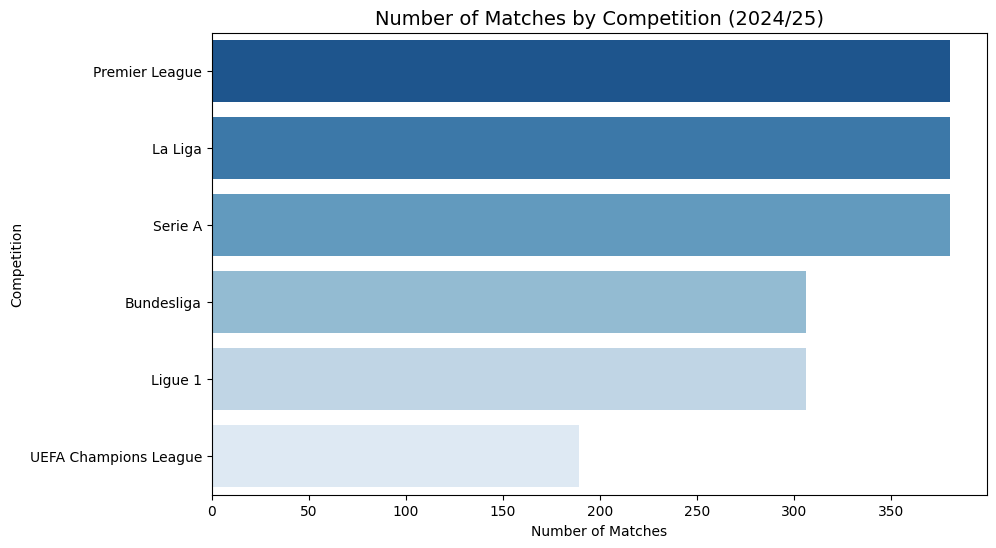

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y="competition_name", order=df["competition_name"].value_counts().index, palette="Blues_r")
plt.title("Number of Matches by Competition (2024/25)", fontsize=14)
plt.xlabel("Number of Matches")
plt.ylabel("Competition")
plt.show()


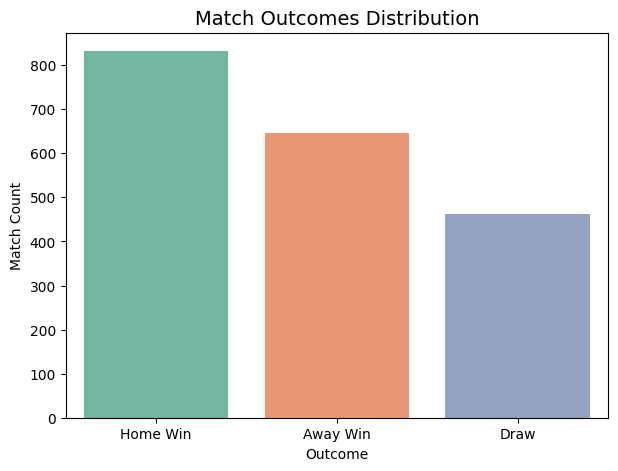

In [13]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="match_outcome", palette="Set2")
plt.title("Match Outcomes Distribution", fontsize=14)
plt.xlabel("Outcome")
plt.ylabel("Match Count")
plt.show()

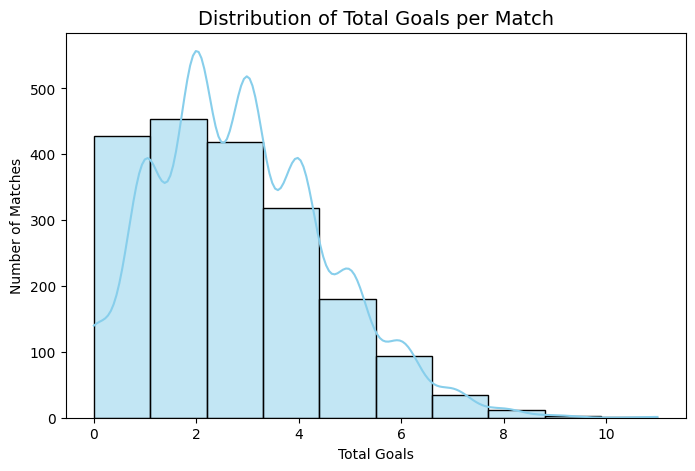

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_goals"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Total Goals per Match", fontsize=14)
plt.xlabel("Total Goals")
plt.ylabel("Number of Matches")
plt.show()

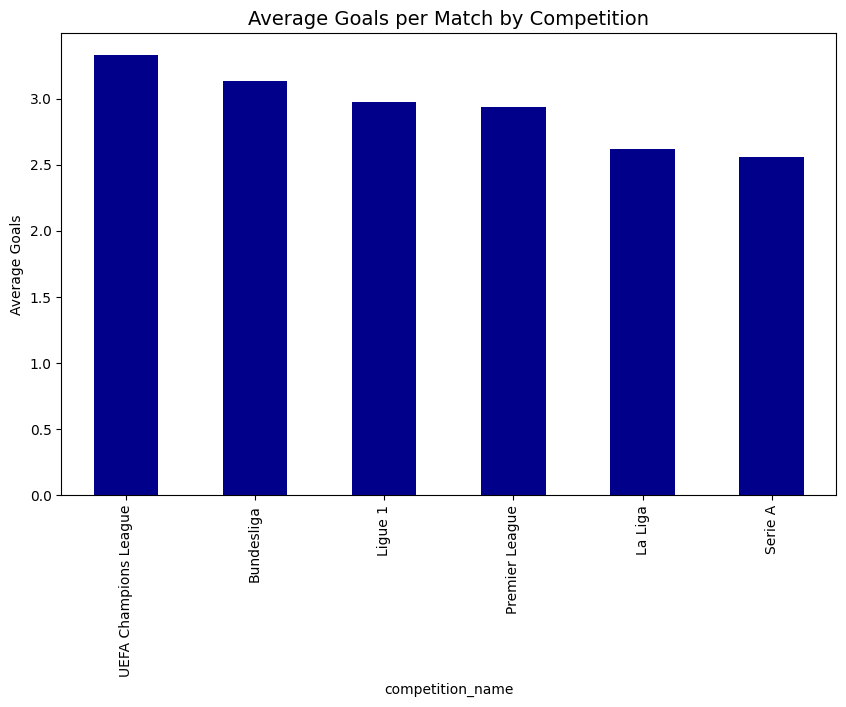

In [15]:
avg_goals = df.groupby("competition_name")["total_goals"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
avg_goals.plot(kind="bar", color="darkblue")
plt.title("Average Goals per Match by Competition", fontsize=14)
plt.ylabel("Average Goals")
plt.show()


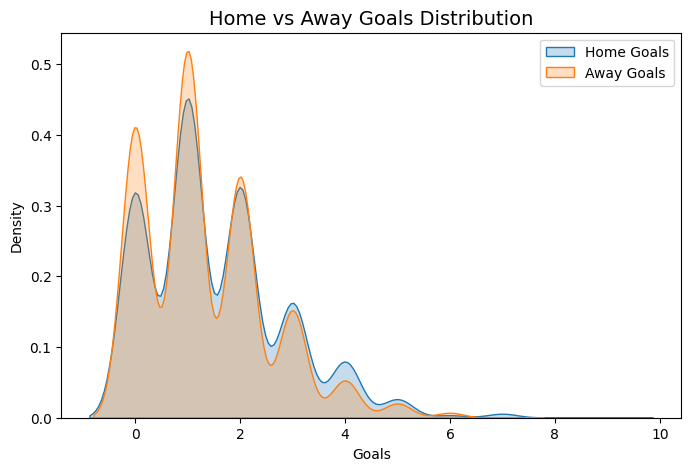

In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["fulltime_home"], fill=True, label="Home Goals")
sns.kdeplot(df["fulltime_away"], fill=True, label="Away Goals")
plt.title("Home vs Away Goals Distribution", fontsize=14)
plt.xlabel("Goals")
plt.ylabel("Density")
plt.legend()
plt.show()

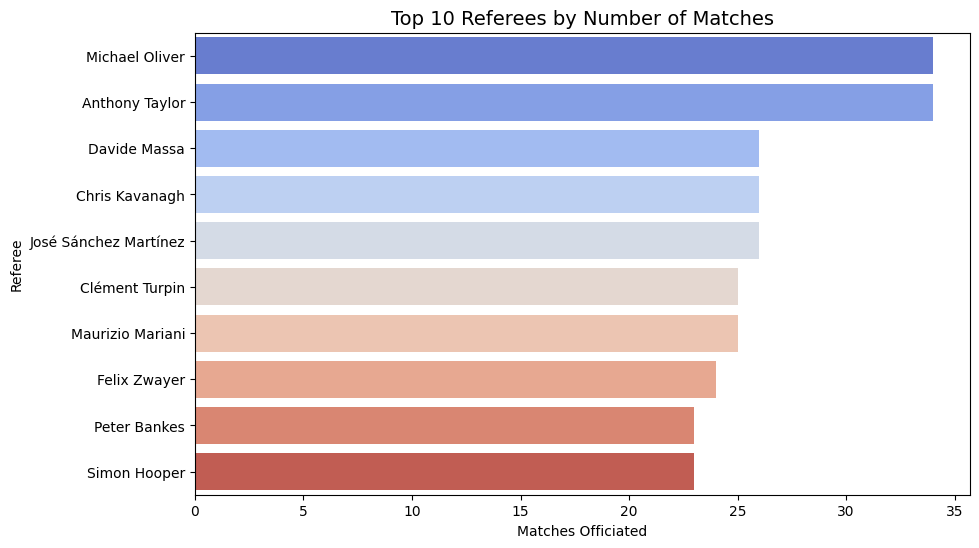

In [17]:
plt.figure(figsize=(10,6))
top_referees = df["referee"].value_counts().head(10)
sns.barplot(x=top_referees.values, y=top_referees.index, palette="coolwarm")
plt.title("Top 10 Referees by Number of Matches", fontsize=14)
plt.xlabel("Matches Officiated")
plt.ylabel("Referee")
plt.show()

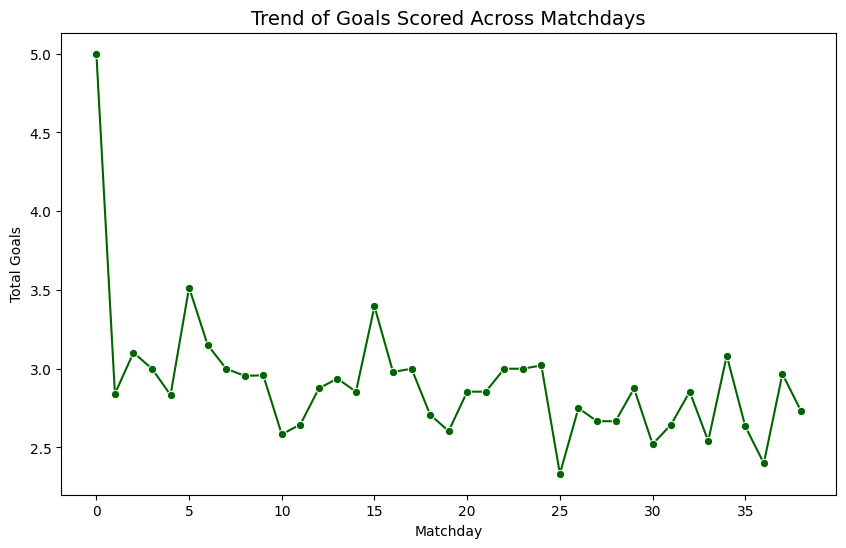

In [18]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="matchday", y="total_goals", ci=None, marker="o", color="darkgreen")
plt.title("Trend of Goals Scored Across Matchdays", fontsize=14)
plt.xlabel("Matchday")
plt.ylabel("Total Goals")
plt.show()

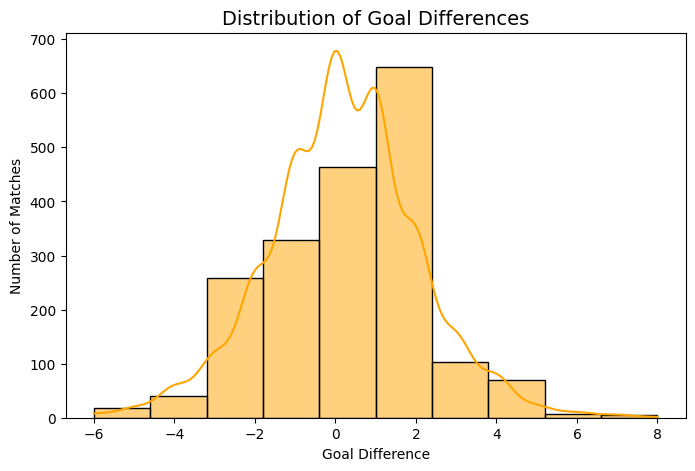

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["goal_difference"], bins=10, kde=True, color="orange")
plt.title("Distribution of Goal Differences", fontsize=14)
plt.xlabel("Goal Difference")
plt.ylabel("Number of Matches")
plt.show()

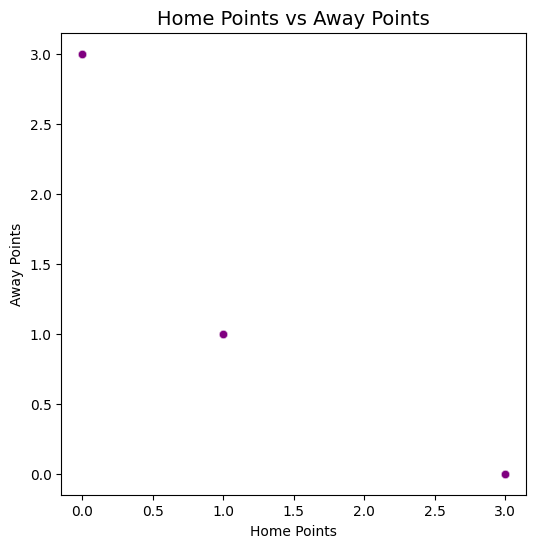

In [20]:
plt.figure(figsize=(6,6))
sns.scatterplot(x="home_points", y="away_points", data=df, alpha=0.6, color="purple")
plt.title("Home Points vs Away Points", fontsize=14)
plt.xlabel("Home Points")
plt.ylabel("Away Points")
plt.show()

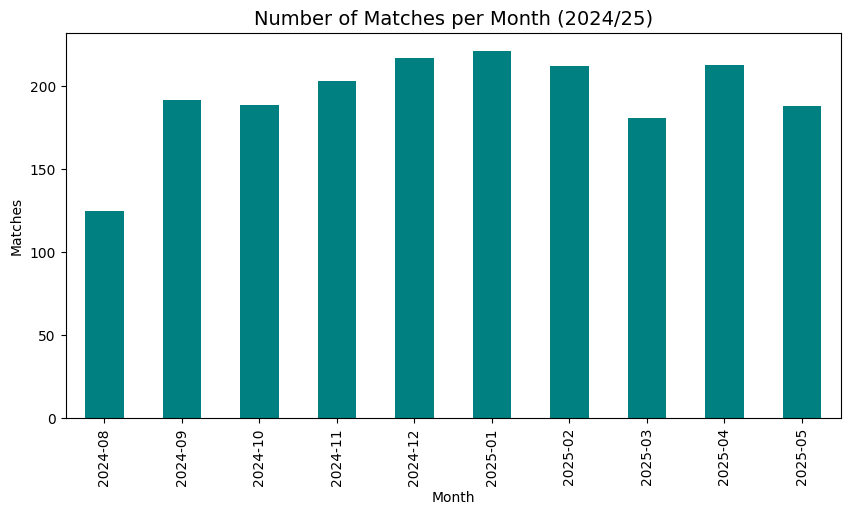

In [21]:
df["date_utc"] = pd.to_datetime(df["date_utc"])
matches_per_month = df.groupby(df["date_utc"].dt.to_period("M")).size()

plt.figure(figsize=(10,5))
matches_per_month.plot(kind="bar", color="teal")
plt.title("Number of Matches per Month (2024/25)", fontsize=14)
plt.ylabel("Matches")
plt.xlabel("Month")
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [23]:
target = "match_outcome"
drop_cols = ["match_id", "date_utc", "date_local_africa_cairo", "referee"]

X = df.drop(columns=[target] + drop_cols, errors="ignore")
y = df[target]

label_encoders = {}
for col in X.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(y)

imputer = SimpleImputer(strategy="most_frequent")   # use most frequent for mixed data
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}


In [25]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name:25}: {acc:.2f} %")


Logistic Regression      : 100.00 %
Decision Tree            : 100.00 %
Random Forest            : 100.00 %
Gradient Boosting        : 100.00 %
KNN                      : 44.47 %
SVM                      : 43.19 %


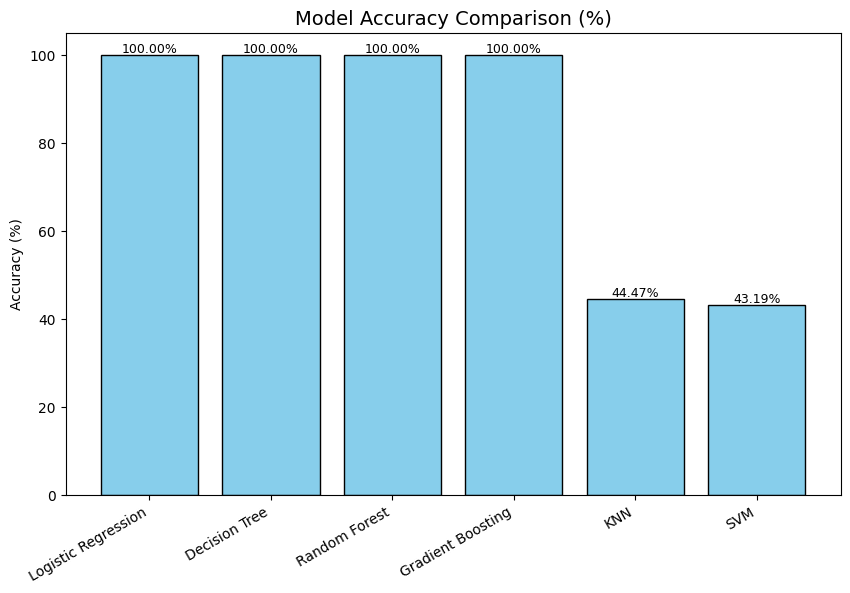

In [26]:
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color="skyblue", edgecolor="black")
plt.title("Model Accuracy Comparison (%)", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha="center", fontsize=9)
plt.show()

## Thank you..pls upvote!!!